<a href="https://colab.research.google.com/github/Prarthana-06/CODESOFT/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

# Imbalance
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

# Explainability
import shap

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries loaded!')

✅ All libraries loaded!


In [2]:
from google.colab import files
uploaded = files.upload()   # Upload Churn_Modelling.csv

df = pd.read_csv('Churn_Modelling.csv')

# Drop irrelevant columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

print(f'Shape: {df.shape}')
print(f'\nChurn Rate: {df["Exited"].mean()*100:.2f}%')
print(f'\nData Types:\n{df.dtypes}')
print(f'\nMissing Values:\n{df.isnull().sum()}')
df.head()

Saving Churn_Modelling.csv to Churn_Modelling.csv
Shape: (10000, 11)

Churn Rate: 20.37%

Data Types:
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


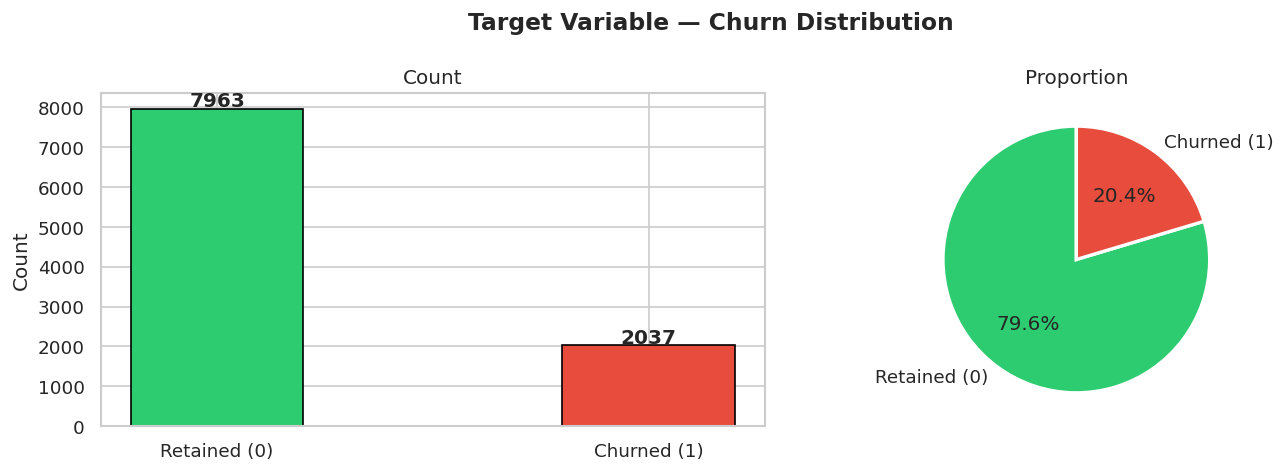

In [3]:
# ── 3a. Target distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable — Churn Distribution', fontsize=14, fontweight='bold')

counts = df['Exited'].value_counts()
labels = ['Retained (0)', 'Churned (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', width=0.4)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('Count')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

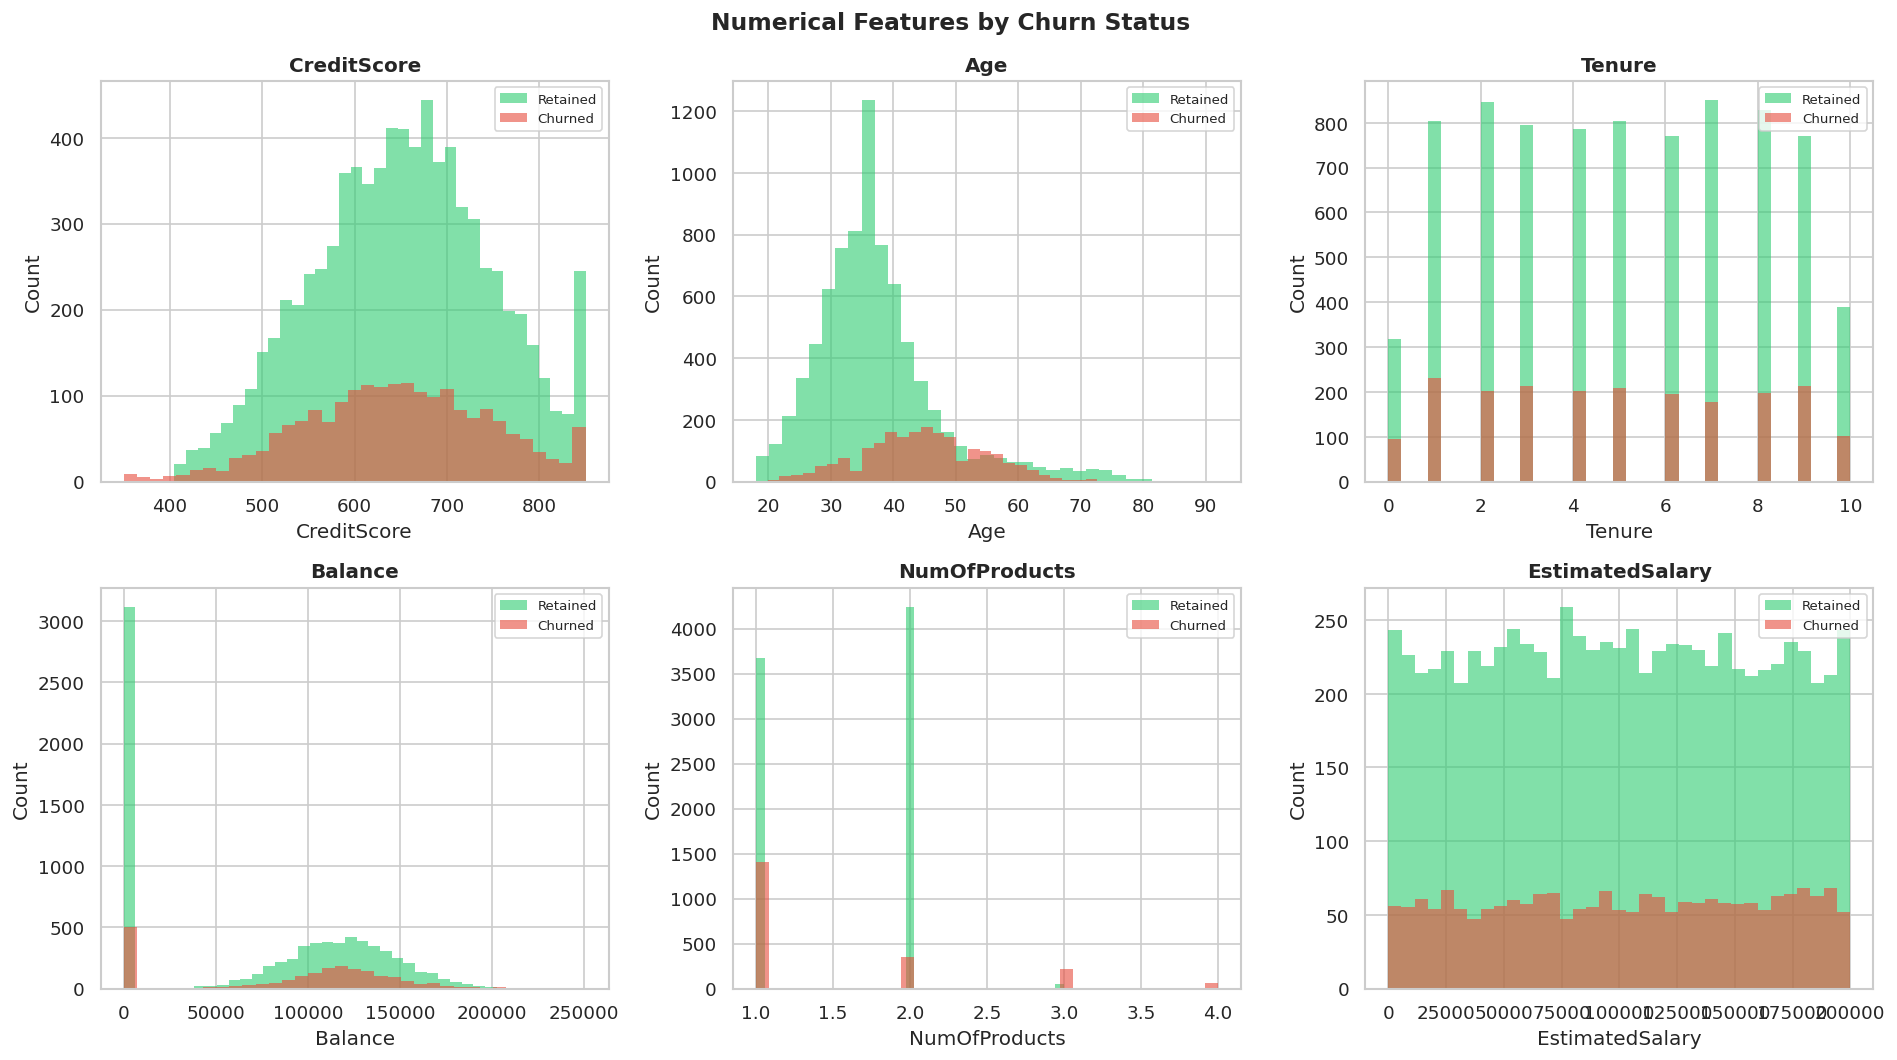

In [4]:
# ── 3b. Numerical feature distributions by churn ─────────────────
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Numerical Features by Churn Status', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, num_cols):
    for label, color, name in [(0, '#2ecc71', 'Retained'), (1, '#e74c3c', 'Churned')]:
        ax.hist(df[df['Exited'] == label][col], bins=35,
                alpha=0.6, color=color, label=name, edgecolor='none')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

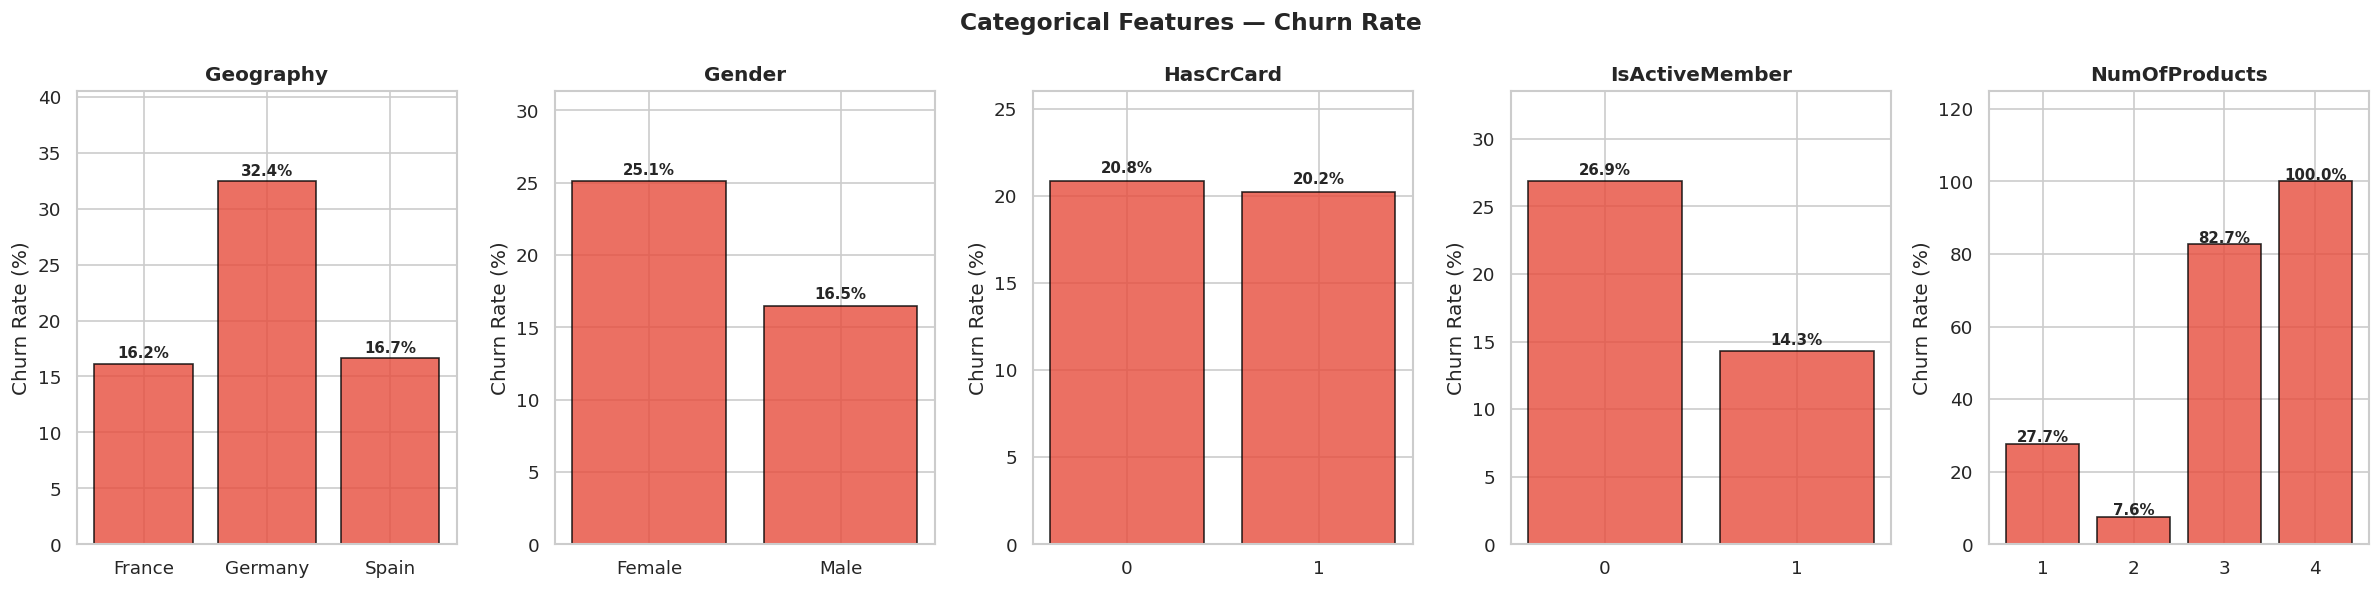

In [5]:
# ── 3c. Categorical features vs Churn ────────────────────────────
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 5))
fig.suptitle('Categorical Features — Churn Rate', fontsize=14, fontweight='bold')

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Exited'].mean() * 100
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values,
                  color='#e74c3c', alpha=0.8, edgecolor='black')
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, churn_rate.max() * 1.25)

plt.tight_layout()
plt.savefig('categorical_churn.png', dpi=150, bbox_inches='tight')
plt.show()

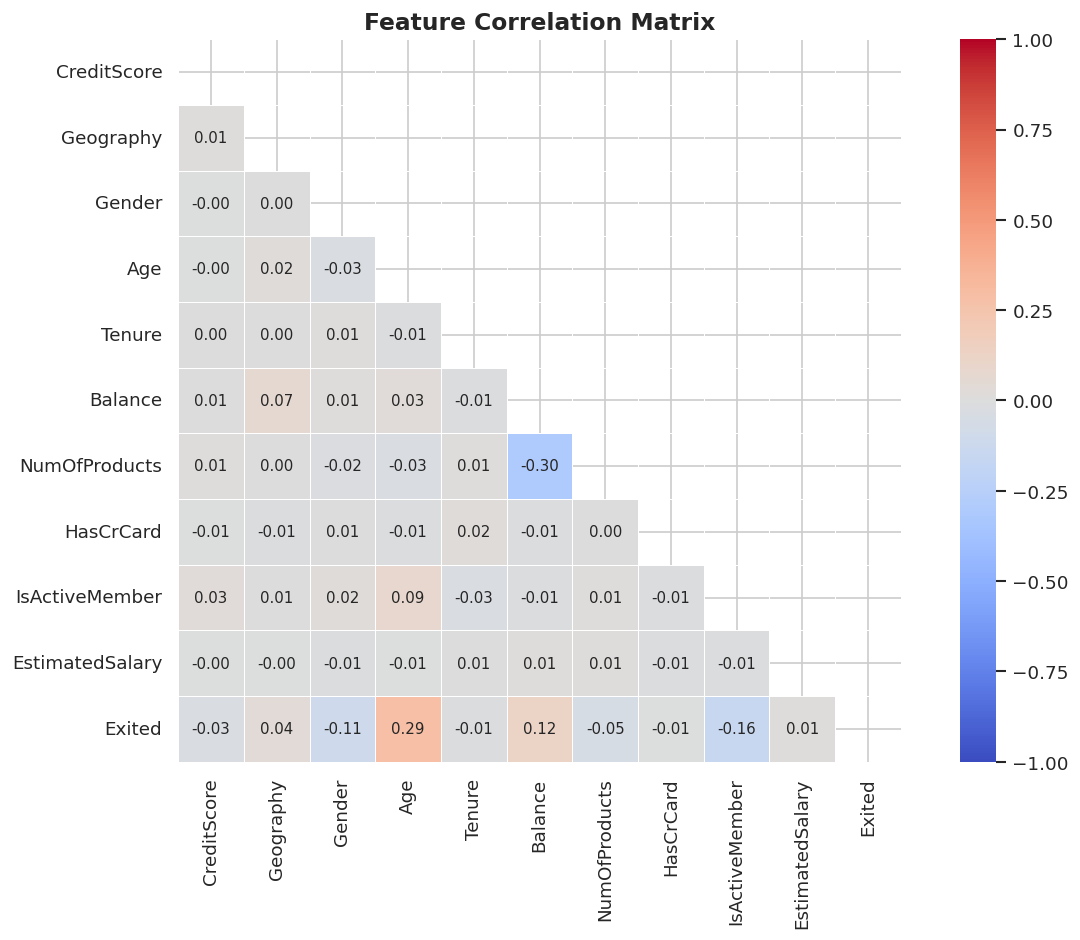

In [6]:
# ── 3d. Correlation Heatmap ───────────────────────────────────────
df_corr = df.copy()
le_geo    = LabelEncoder()
le_gender = LabelEncoder()
df_corr['Geography'] = le_geo.fit_transform(df_corr['Geography'])
df_corr['Gender']    = le_gender.fit_transform(df_corr['Gender'])

plt.figure(figsize=(11, 8))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, square=True, annot_kws={'size': 9})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
df_model = df.copy()

# ── New engineered features ──────────────────────────────────────
df_model['BalanceSalaryRatio']   = df_model['Balance'] / (df_model['EstimatedSalary'] + 1)
df_model['CreditScorePerAge']    = df_model['CreditScore'] / df_model['Age']
df_model['ProductsPerTenure']    = df_model['NumOfProducts'] / (df_model['Tenure'] + 1)
df_model['ZeroBalance']          = (df_model['Balance'] == 0).astype(int)
df_model['SeniorCustomer']       = (df_model['Age'] >= 45).astype(int)
df_model['ActiveWithCrCard']     = df_model['IsActiveMember'] * df_model['HasCrCard']

print('✅ Engineered features added:')
new_feats = ['BalanceSalaryRatio','CreditScorePerAge','ProductsPerTenure',
             'ZeroBalance','SeniorCustomer','ActiveWithCrCard']
print(df_model[new_feats].describe().round(3))

✅ Engineered features added:
       BalanceSalaryRatio  CreditScorePerAge  ProductsPerTenure  ZeroBalance  \
count           10000.000          10000.000          10000.000    10000.000   
mean                3.790             17.874              0.367        0.362   
std               100.056              5.376              0.338        0.481   
min                 0.000              4.857              0.091        0.000   
25%                 0.000             14.089              0.167        0.000   
50%                 0.747             17.286              0.250        0.000   
75%                 1.514             20.962              0.500        1.000   
max              9770.883             46.889              3.000        1.000   

       SeniorCustomer  ActiveWithCrCard  
count       10000.000         10000.000  
mean            0.234             0.361  
std             0.423             0.480  
min             0.000             0.000  
25%             0.000             0.000 

In [8]:
# ── Encode categoricals ──────────────────────────────────────────
df_model = pd.get_dummies(df_model, columns=['Geography', 'Gender'], drop_first=False)

X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]}')
print(f'\nFeature list:\n{list(X.columns)}')

Features : 19
Samples  : 10000

Feature list:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceSalaryRatio', 'CreditScorePerAge', 'ProductsPerTenure', 'ZeroBalance', 'SeniorCustomer', 'ActiveWithCrCard', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f'Train (before SMOTE): {dict(y_train.value_counts())}')
print(f'Train (after  SMOTE): {dict(pd.Series(y_train_sm).value_counts())}')
print(f'Test                : {dict(y_test.value_counts())}')

Train (before SMOTE): {0: np.int64(6370), 1: np.int64(1630)}
Train (after  SMOTE): {1: np.int64(6370), 0: np.int64(6370)}
Test                : {0: np.int64(1593), 1: np.int64(407)}


In [10]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = (model.predict_proba(X_te)[:, 1]
              if hasattr(model, 'predict_proba')
              else model.decision_function(X_te))
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred) * 100, 2),
        'Precision': round(precision_score(y_te, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_te, y_pred) * 100, 2),
        'F1-Score' : round(f1_score(y_te, y_pred) * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_prob) * 100, 2),
    }, y_pred, y_prob, model

models = {
    'Logistic Regression'  : LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=300, max_depth=10,
                                                     random_state=42, n_jobs=-1),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                         max_depth=5, random_state=42),
    'XGBoost'              : XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                                            use_label_encoder=False, eval_metric='logloss',
                                            random_state=42, n_jobs=-1),
}

results, trained, probs = [], {}, {}
print('Training models...\n')
for name, model in models.items():
    m, y_pred, y_prob, fitted = evaluate(name, model,
                                          X_train_sm, X_test_sc,
                                          y_train_sm, y_test)
    results.append(m)
    trained[name] = fitted
    probs[name]   = y_prob
    print(f'  ✅ {name:22s} — Acc: {m["Accuracy"]}%  F1: {m["F1-Score"]}%  AUC: {m["ROC-AUC"]}%')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\n📊 Results Summary:')
display(results_df.reset_index(drop=True))

Training models...

  ✅ Logistic Regression    — Acc: 71.75%  F1: 49.6%  AUC: 77.97%
  ✅ Random Forest          — Acc: 82.8%  F1: 61.26%  AUC: 85.46%
  ✅ Gradient Boosting      — Acc: 85.85%  F1: 61.81%  AUC: 85.91%
  ✅ XGBoost                — Acc: 86.05%  F1: 62.14%  AUC: 85.34%

📊 Results Summary:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,85.85,68.56,56.27,61.81,85.91
1,Random Forest,82.80,56.55,66.83,61.26,85.46
2,XGBoost,86.05,69.39,56.27,62.14,85.34
3,Logistic Regression,71.75,38.94,68.30,49.60,77.97


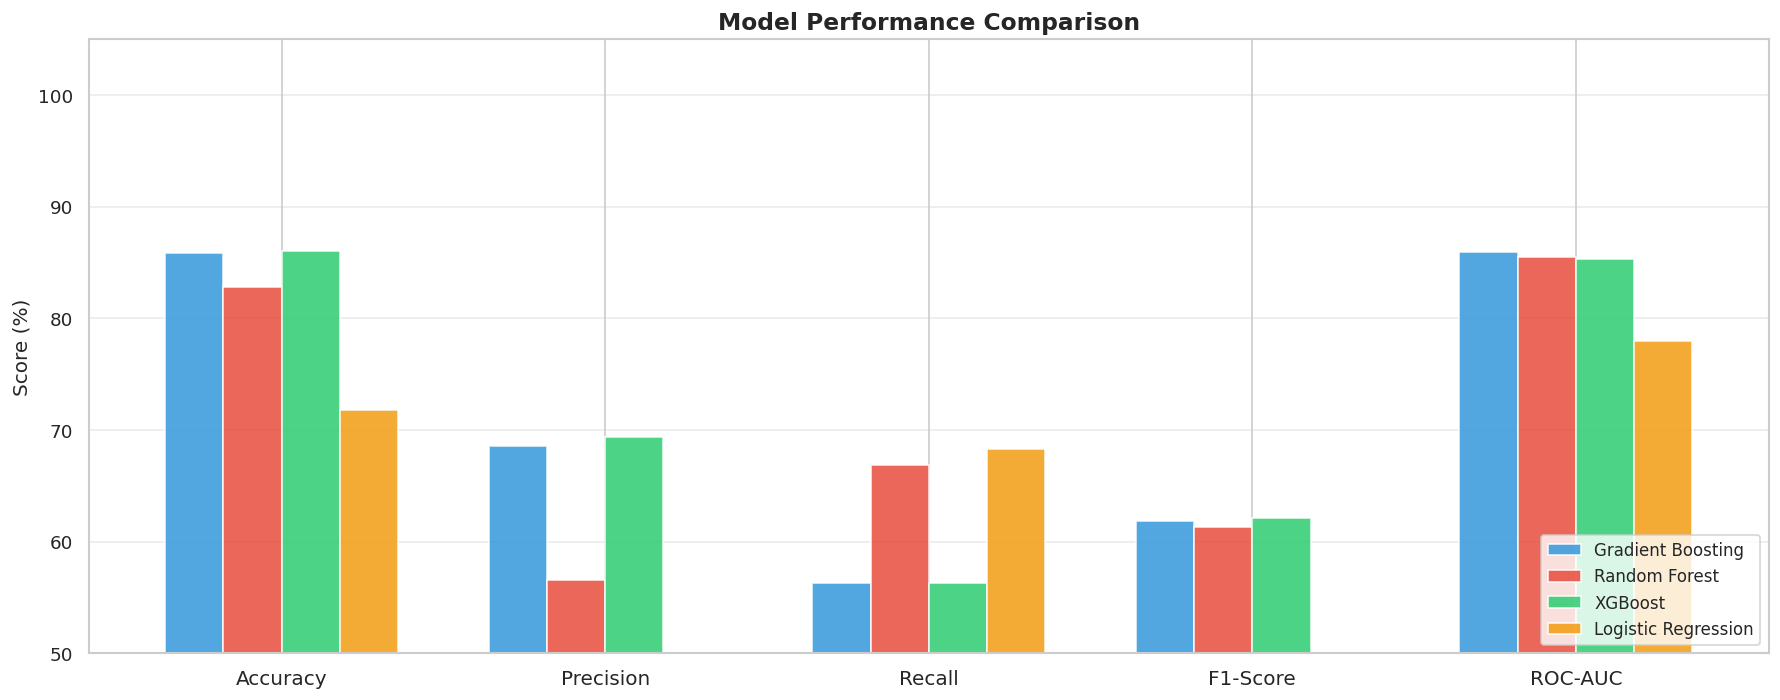

In [11]:
# ── Metrics bar chart ────────────────────────────────────────────
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_cols))
width = 0.18
palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(15, 6))
for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics_cols]
    ax.bar(x + i * width, vals, width, label=row['Model'],
           color=palette[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_cols, fontsize=12)
ax.set_ylim(50, 105)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

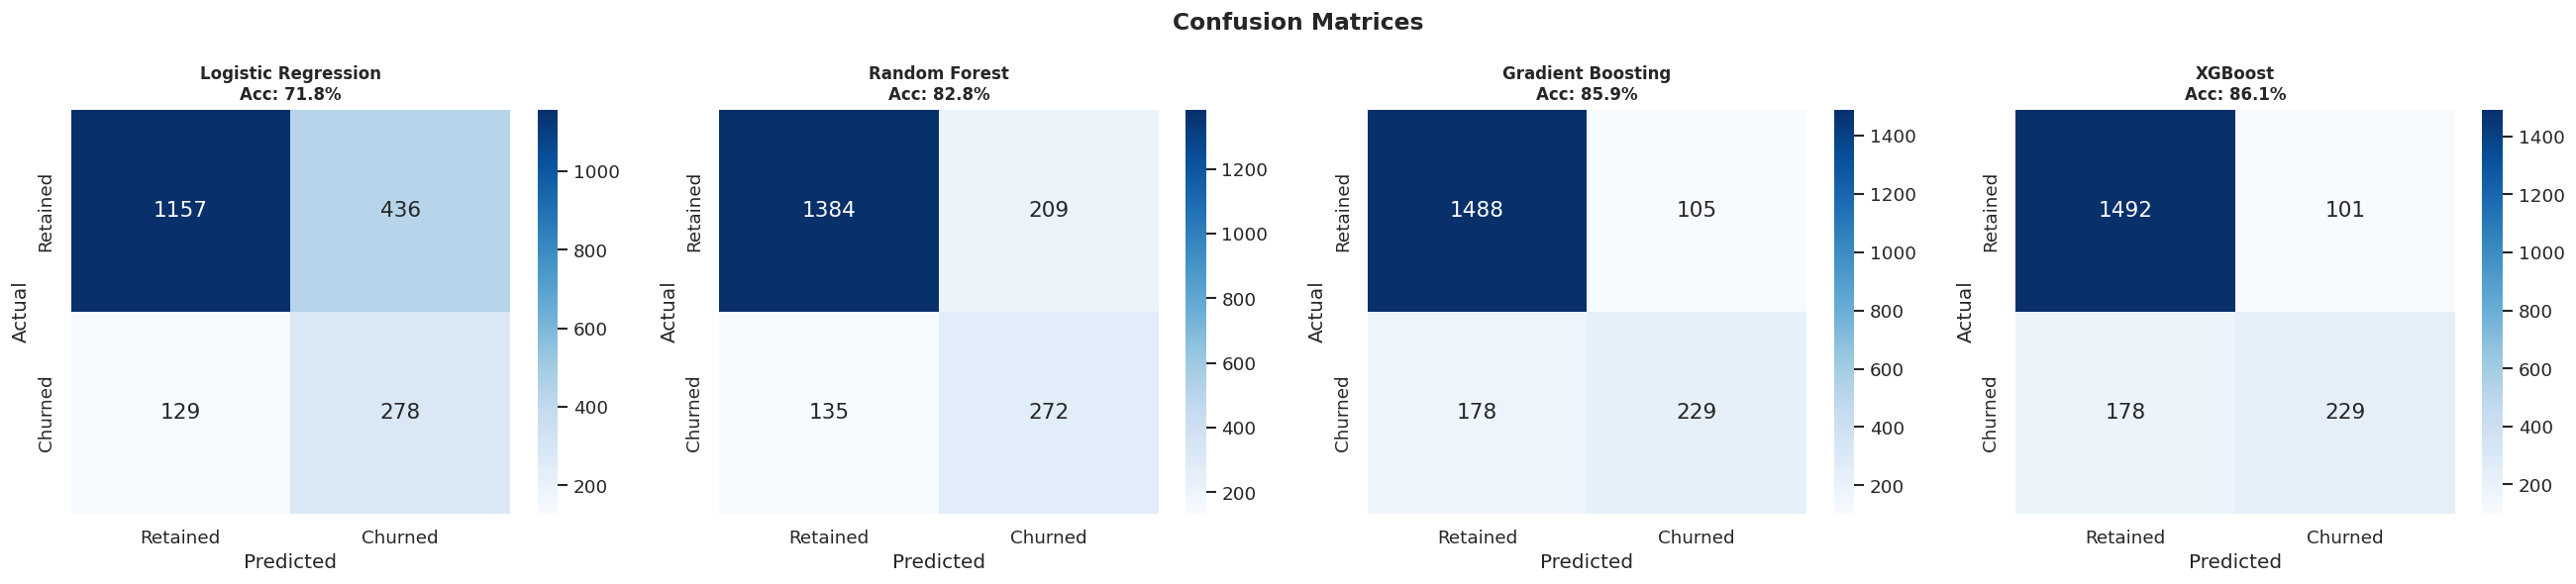

In [12]:
# ── Confusion Matrices ───────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (name, model) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_sc))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'],
                annot_kws={'size': 13})
    acc = accuracy_score(y_test, model.predict(X_test_sc))
    ax.set_title(f'{name}\nAcc: {acc*100:.1f}%', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

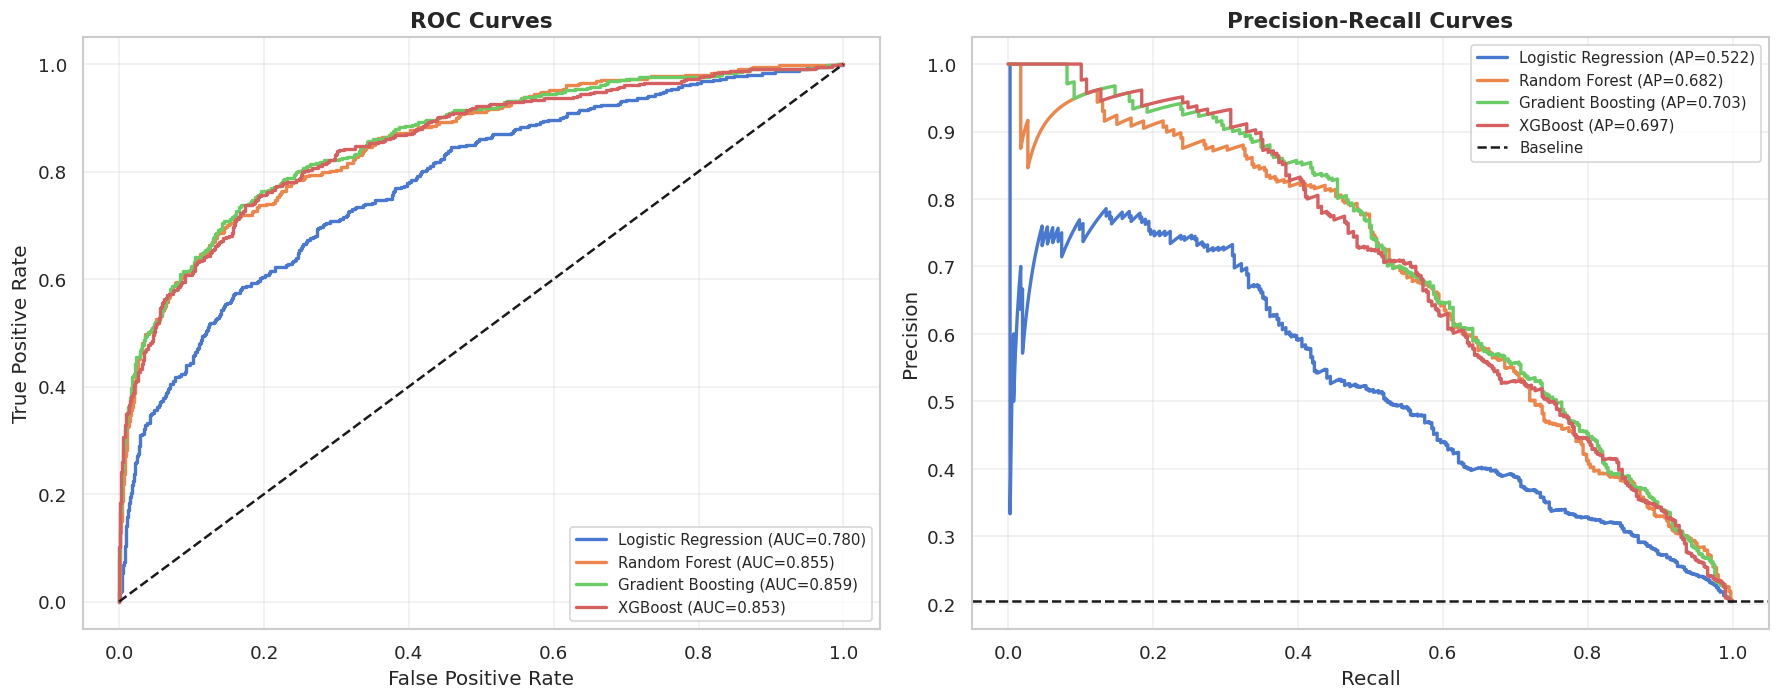

In [13]:
# ── ROC & Precision-Recall Curves ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, y_prob in probs.items():
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')

    # PR
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, lw=2, label=f'{name} (AP={ap:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].axhline(y=df['Exited'].mean(), color='k', linestyle='--', lw=1.5, label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
best_name = results_df.iloc[0]['Model']
print(f' Best model: {best_name} — tuning...')

param_grids = {
    'XGBoost': {
        'n_estimators'  : [100, 200, 300],
        'max_depth'     : [4, 6, 8],
        'learning_rate' : [0.05, 0.1, 0.2],
        'subsample'     : [0.8, 1.0],
    },
    'Random Forest': {
        'n_estimators' : [100, 200, 300],
        'max_depth'    : [8, 10, None],
        'min_samples_split': [2, 5],
    },
    'Gradient Boosting': {
        'n_estimators'  : [100, 200],
        'learning_rate' : [0.05, 0.1],
        'max_depth'     : [3, 5],
    },
    'Logistic Regression': {
        'C'      : [0.01, 0.1, 1, 10],
        'solver' : ['lbfgs', 'saga'],
    }
}

base_model = models[best_name]
grid = GridSearchCV(
    base_model,
    param_grids[best_name],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train_sm, y_train_sm)

print(f'\n Best params: {grid.best_params_}')
print(f'   CV ROC-AUC : {grid.best_score_*100:.2f}%')

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_sc)
y_prob_best = best_model.predict_proba(X_test_sc)[:, 1]

print(f'\n Tuned Model — Test Set Results:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_best)*100:.2f}%')
print(f'  Precision : {precision_score(y_test, y_pred_best)*100:.2f}%')
print(f'  Recall    : {recall_score(y_test, y_pred_best)*100:.2f}%')
print(f'  F1-Score  : {f1_score(y_test, y_pred_best)*100:.2f}%')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_best)*100:.2f}%')

 Best model: Gradient Boosting — tuning...

 Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
   CV ROC-AUC : 96.30%

📋 Tuned Model — Test Set Results:
  Accuracy  : 85.85%
  Precision : 68.56%
  Recall    : 56.27%
  F1-Score  : 61.81%
  ROC-AUC   : 85.91%


10-Fold CV ROC-AUC Scores:
  [85.21 86.72 88.74 80.9  85.37 86.62 86.82 84.98 87.09 86.12]

  Mean : 85.86%
  Std  : 1.95%


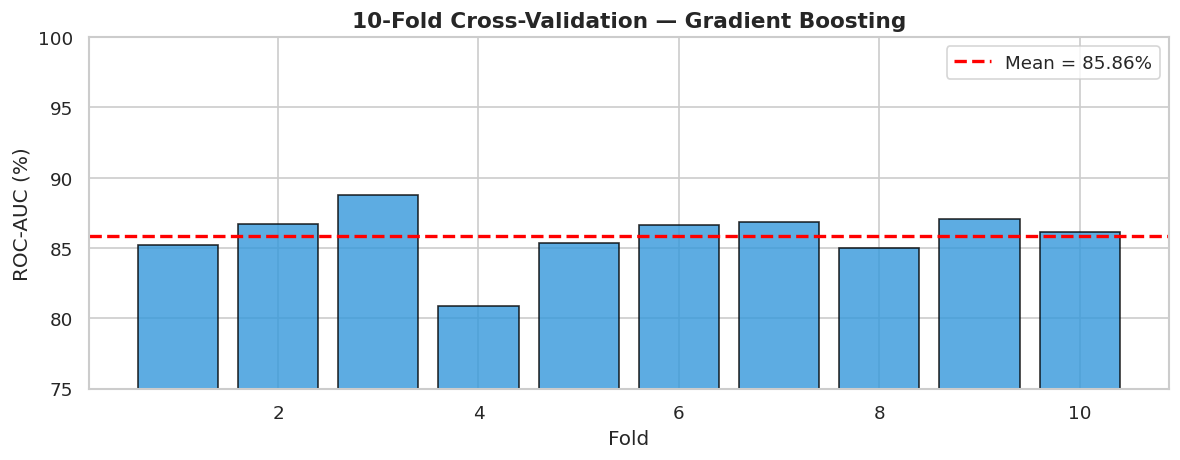

In [16]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Use full scaled data (without SMOTE) for honest CV
X_sc_full = scaler.fit_transform(X)
cv_scores = cross_val_score(best_model, X_sc_full, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'10-Fold CV ROC-AUC Scores:')
print(f'  {np.round(cv_scores * 100, 2)}')
print(f'\n  Mean : {cv_scores.mean()*100:.2f}%')
print(f'  Std  : {cv_scores.std()*100:.2f}%')

plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), cv_scores * 100, color='#3498db', edgecolor='black', alpha=0.8)
plt.axhline(cv_scores.mean() * 100, color='red', linestyle='--', lw=2,
            label=f'Mean = {cv_scores.mean()*100:.2f}%')
plt.xlabel('Fold'); plt.ylabel('ROC-AUC (%)')
plt.title(f'10-Fold Cross-Validation — {best_name}', fontsize=13, fontweight='bold')
plt.legend(); plt.ylim(75, 100)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

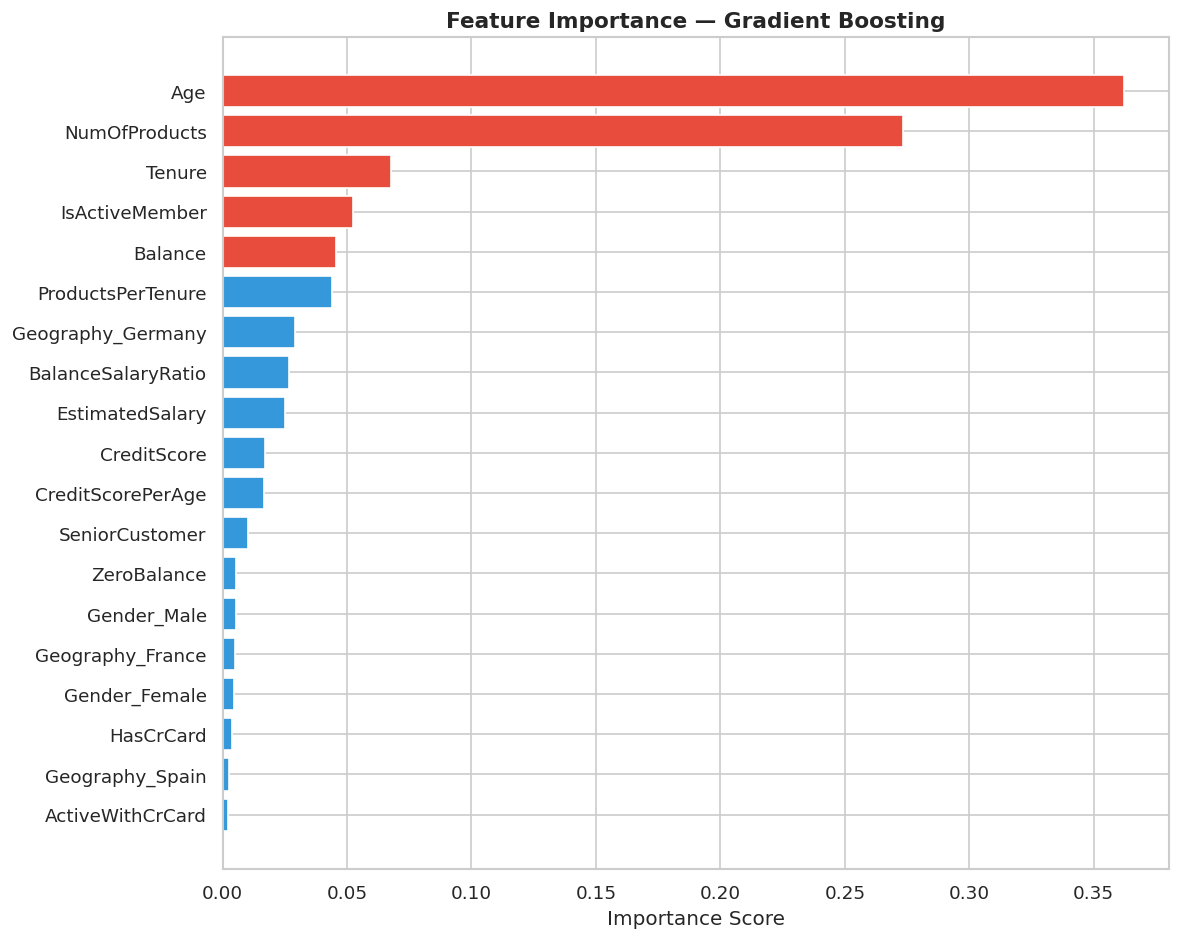


🔝 Top 10 most important features:
           Feature  Importance
               Age    0.362037
     NumOfProducts    0.273408
            Tenure    0.067751
    IsActiveMember    0.052591
           Balance    0.045678
 ProductsPerTenure    0.044107
 Geography_Germany    0.029063
BalanceSalaryRatio    0.026630
   EstimatedSalary    0.025128
       CreditScore    0.017103


In [17]:
feature_names = list(X.columns)

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 8))
    colors = ['#e74c3c' if i >= len(fi_df) - 5 else '#3498db'
              for i in range(len(fi_df))]
    plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors, edgecolor='white')
    plt.xlabel('Importance Score', fontsize=12)
    plt.title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n🔝 Top 10 most important features:')
    print(fi_df.sort_values('Importance', ascending=False).head(10).to_string(index=False))

elif hasattr(best_model, 'coef_'):
    coefs = best_model.coef_[0]
    fi_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
    fi_df = fi_df.reindex(fi_df['Coefficient'].abs().sort_values(ascending=True).index)
    plt.figure(figsize=(10, 8))
    plt.barh(fi_df['Feature'], fi_df['Coefficient'],
             color=['#e74c3c' if c > 0 else '#2ecc71' for c in fi_df['Coefficient']])
    plt.axvline(0, color='black', lw=0.8)
    plt.xlabel('Coefficient', fontsize=12)
    plt.title('Logistic Regression Coefficients', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

Computing SHAP values (this may take ~30 seconds)...


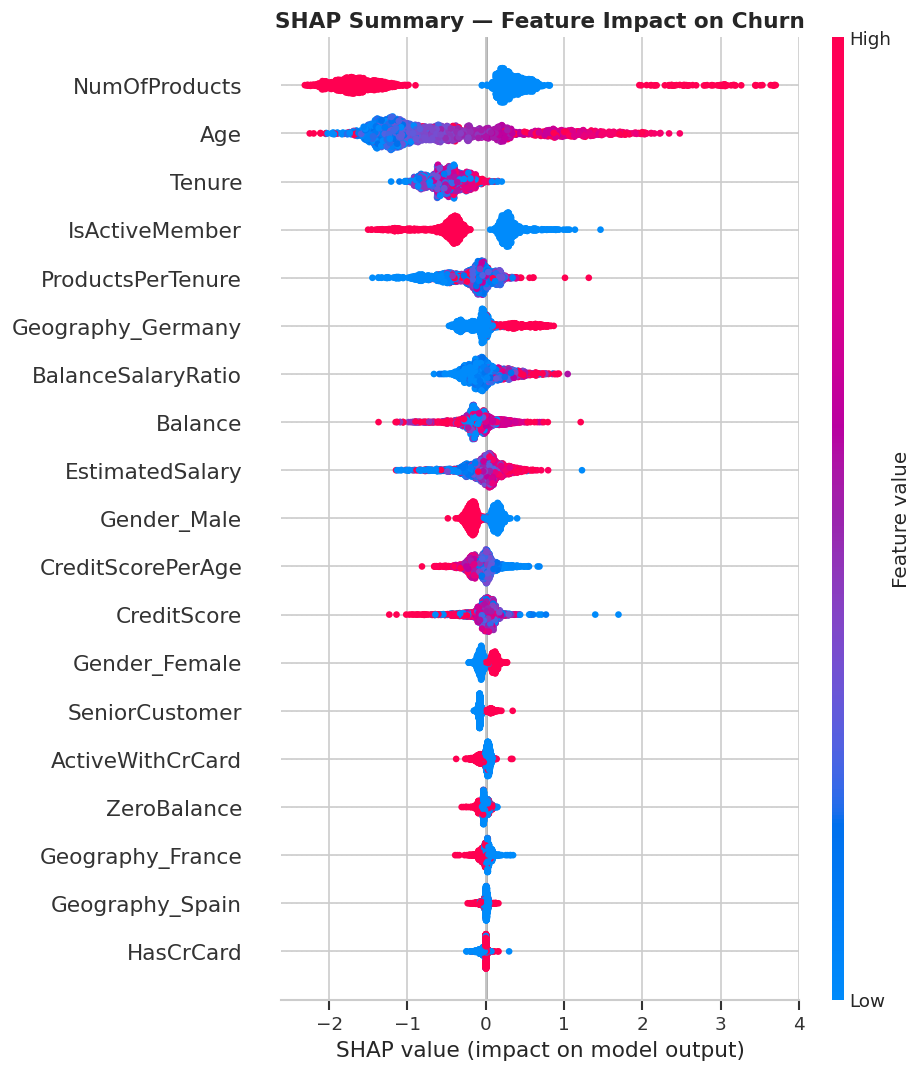

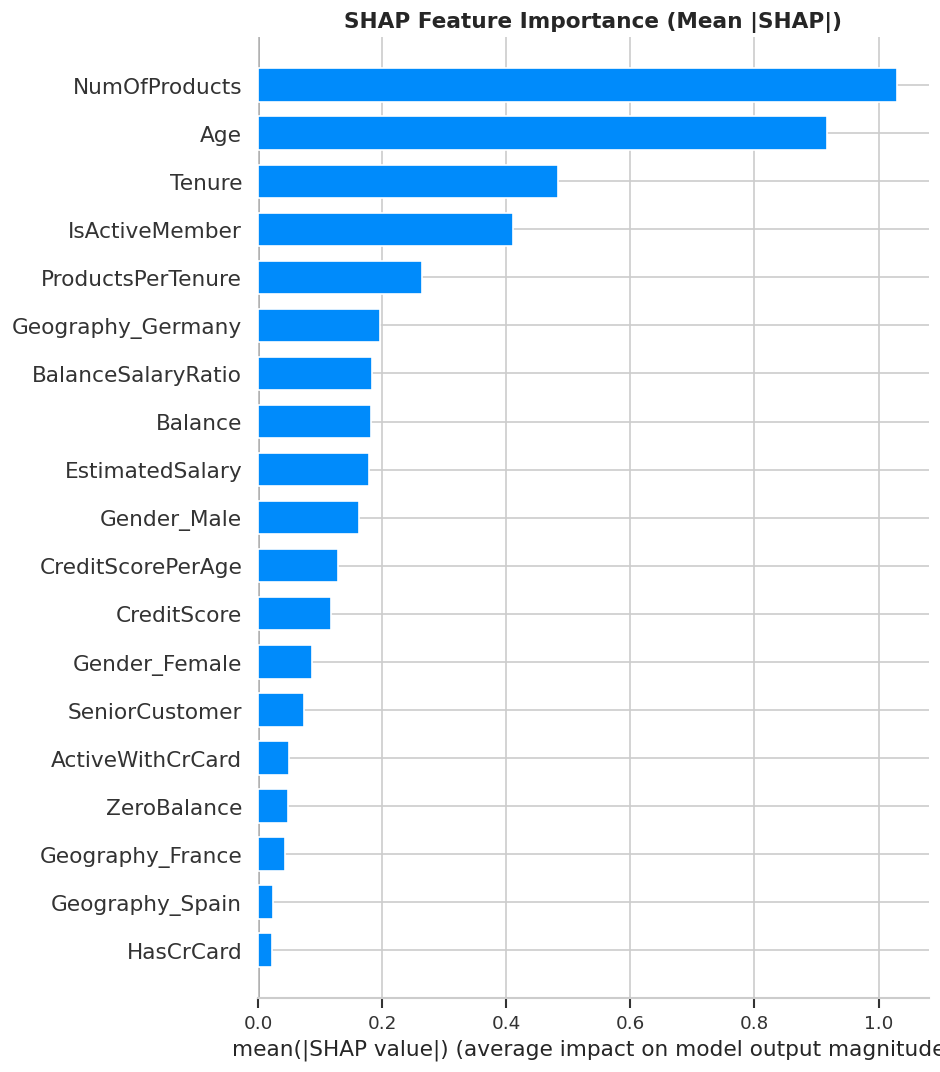

In [18]:
print('Computing SHAP values (this may take ~30 seconds)...')

X_test_df = pd.DataFrame(X_test_sc, columns=feature_names)

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_df)

# Handle binary classification shape
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# ── SHAP Summary (Beeswarm) ──────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test_df, show=False)
plt.title('SHAP Summary — Feature Impact on Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SHAP Bar (Mean Absolute) ─────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test_df, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

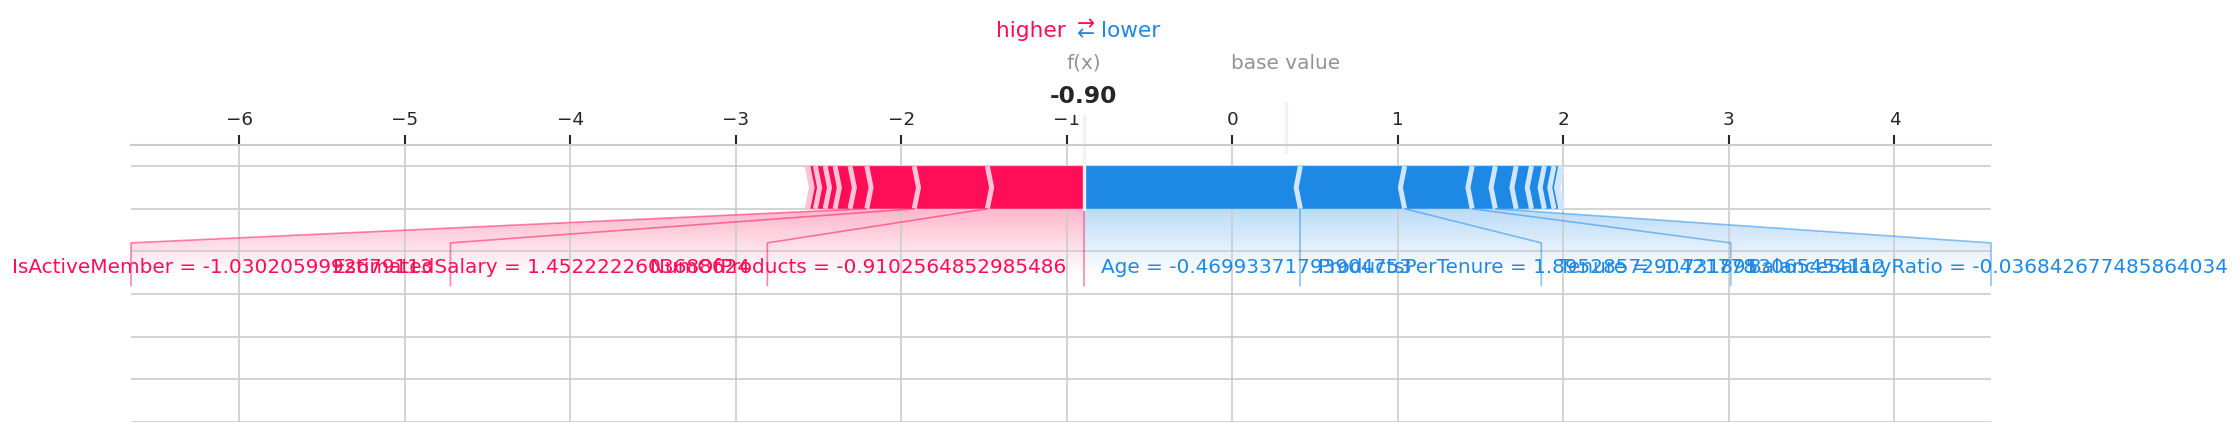

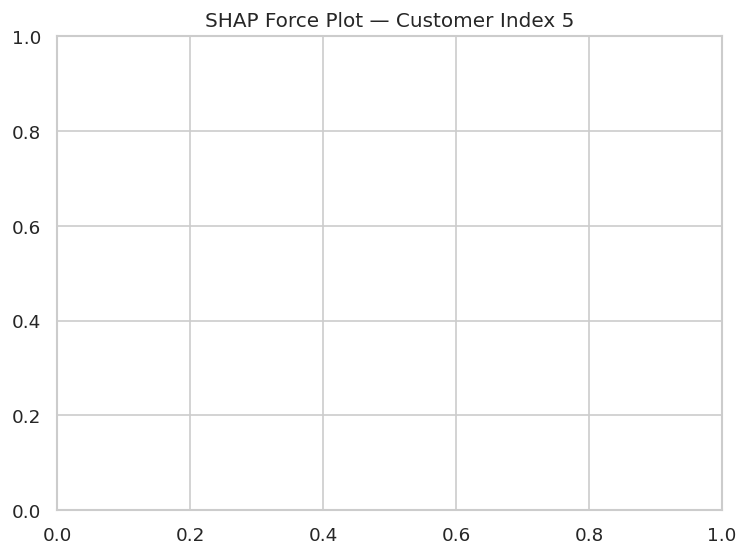

In [19]:
# ── SHAP Waterfall — explain a single prediction ─────────────────
idx = 5   # change this index to explain different customers

shap.initjs()
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list)
    else explainer.expected_value,
    sv[idx],
    X_test_df.iloc[idx],
    matplotlib=True
)
plt.title(f'SHAP Force Plot — Customer Index {idx}', fontsize=12)
plt.tight_layout()
plt.savefig('shap_force.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Churn Risk Segments:


,RiskSegment,Count,AvgChurnProb,ActualChurnRate
0,🔴 High Risk,175,89.4,86.3
1,🟡 Medium Risk,197,59.1,45.7
2,🟢 Low Risk,1628,12.2,10.2


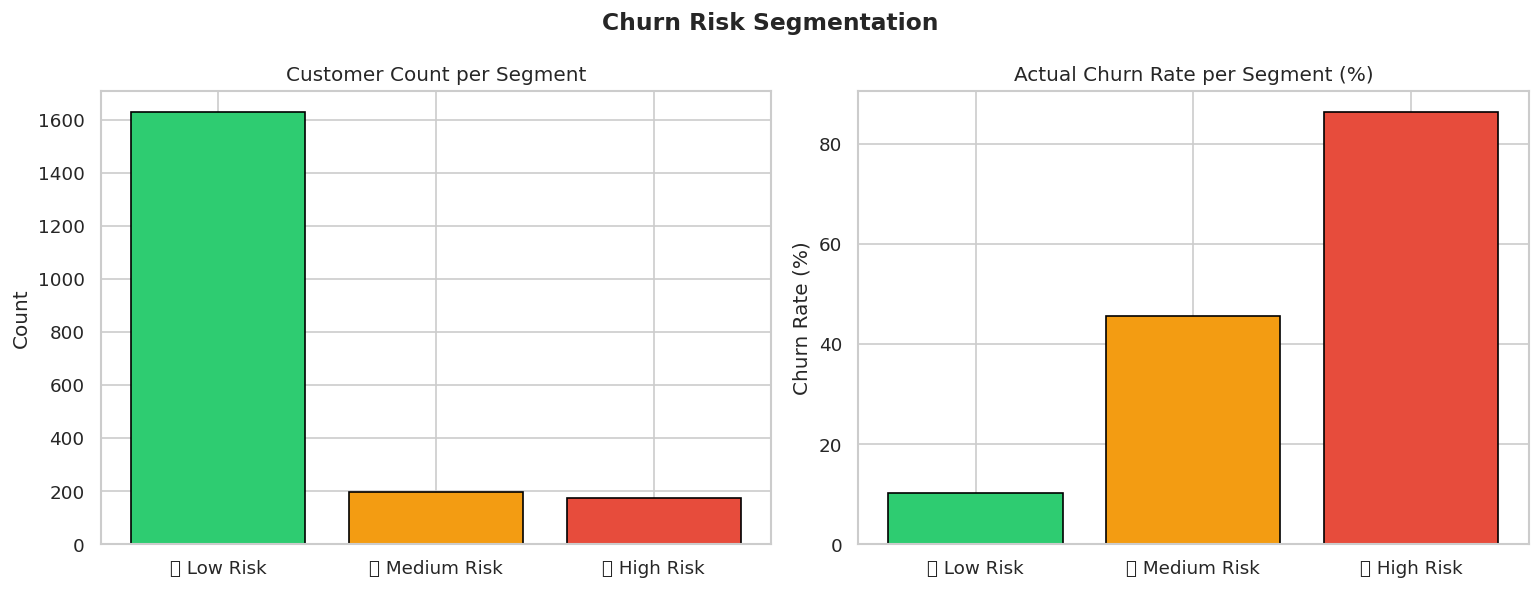

In [20]:
X_test_orig = X_test.copy().reset_index(drop=True)
X_test_orig['ChurnProbability'] = y_prob_best
X_test_orig['ActualChurn']      = y_test.reset_index(drop=True)

def risk_segment(p):
    if p >= 0.75: return '🔴 High Risk'
    elif p >= 0.45: return '🟡 Medium Risk'
    else: return '🟢 Low Risk'

X_test_orig['RiskSegment'] = X_test_orig['ChurnProbability'].apply(risk_segment)

seg_summary = X_test_orig.groupby('RiskSegment').agg(
    Count=('ChurnProbability', 'count'),
    AvgChurnProb=('ChurnProbability', 'mean'),
    ActualChurnRate=('ActualChurn', 'mean')
).reset_index()
seg_summary['AvgChurnProb']    = (seg_summary['AvgChurnProb'] * 100).round(1)
seg_summary['ActualChurnRate'] = (seg_summary['ActualChurnRate'] * 100).round(1)

print('📊 Churn Risk Segments:')
display(seg_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Churn Risk Segmentation', fontsize=14, fontweight='bold')

order = ['🟢 Low Risk', '🟡 Medium Risk', '🔴 High Risk']
seg_filt = seg_summary.set_index('RiskSegment').reindex(order).reset_index()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].bar(seg_filt['RiskSegment'], seg_filt['Count'], color=colors, edgecolor='black')
axes[0].set_title('Customer Count per Segment')
axes[0].set_ylabel('Count')

axes[1].bar(seg_filt['RiskSegment'], seg_filt['ActualChurnRate'], color=colors, edgecolor='black')
axes[1].set_title('Actual Churn Rate per Segment (%)')
axes[1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('risk_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
def predict_churn(credit_score, geography, gender, age, tenure,
                  balance, num_products, has_cr_card, is_active, salary):
    """Predict churn probability for a single customer."""

    row = {
        'CreditScore'     : credit_score,
        'Age'             : age,
        'Tenure'          : tenure,
        'Balance'         : balance,
        'NumOfProducts'   : num_products,
        'HasCrCard'       : has_cr_card,
        'IsActiveMember'  : is_active,
        'EstimatedSalary' : salary,
        # Engineered
        'BalanceSalaryRatio' : balance / (salary + 1),
        'CreditScorePerAge'  : credit_score / age,
        'ProductsPerTenure'  : num_products / (tenure + 1),
        'ZeroBalance'        : int(balance == 0),
        'SeniorCustomer'     : int(age >= 45),
        'ActiveWithCrCard'   : is_active * has_cr_card,
        # One-hot Geography
        'Geography_France' : int(geography == 'France'),
        'Geography_Germany': int(geography == 'Germany'),
        'Geography_Spain'  : int(geography == 'Spain'),
        # One-hot Gender
        'Gender_Female'    : int(gender == 'Female'),
        'Gender_Male'      : int(gender == 'Male'),
    }

    inp_df  = pd.DataFrame([row])[feature_names]   # ensure column order
    inp_sc  = scaler.transform(inp_df)
    prob    = best_model.predict_proba(inp_sc)[0][1]
    risk    = risk_segment(prob)

    print('='*55)
    print(f'  🏦 Customer Churn Risk Report')
    print('='*55)
    print(f'  Geography    : {geography}')
    print(f'  Gender       : {gender}')
    print(f'  Age          : {age}  |  Tenure: {tenure} yrs')
    print(f'  Credit Score : {credit_score}')
    print(f'  Balance      : ${balance:,.0f}  |  Salary: ${salary:,.0f}')
    print(f'  Products     : {num_products}  |  Active: {bool(is_active)}  |  CrCard: {bool(has_cr_card)}')
    print('-'*55)
    print(f'  Churn Probability : {prob*100:.1f}%')
    print(f'  Risk Segment      : {risk}')
    print('='*55)


# ── Example customers ────────────────────────────────────────────
print('\n--- Customer 1 (likely to churn) ---')
predict_churn(credit_score=400, geography='Germany', gender='Female',
              age=55, tenure=1, balance=120000, num_products=1,
              has_cr_card=0, is_active=0, salary=60000)

print('\n--- Customer 2 (likely to stay) ---')
predict_churn(credit_score=750, geography='France', gender='Male',
              age=32, tenure=7, balance=0, num_products=2,
              has_cr_card=1, is_active=1, salary=95000)


--- Customer 1 (likely to churn) ---
  🏦 Customer Churn Risk Report
  Geography    : Germany
  Gender       : Female
  Age          : 55  |  Tenure: 1 yrs
  Credit Score : 400
  Balance      : $120,000  |  Salary: $60,000
  Products     : 1  |  Active: False  |  CrCard: False
-------------------------------------------------------
  Churn Probability : 99.8%
  Risk Segment      : 🔴 High Risk

--- Customer 2 (likely to stay) ---
  🏦 Customer Churn Risk Report
  Geography    : France
  Gender       : Male
  Age          : 32  |  Tenure: 7 yrs
  Credit Score : 750
  Balance      : $0  |  Salary: $95,000
  Products     : 2  |  Active: True  |  CrCard: True
-------------------------------------------------------
  Churn Probability : 93.2%
  Risk Segment      : 🔴 High Risk


In [22]:
import pickle

bundle = {
    'model'        : best_model,
    'scaler'       : scaler,
    'feature_names': feature_names,
    'model_name'   : best_name,
}

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print('✅ Model saved as churn_model.pkl')

from google.colab import files
files.download('churn_model.pkl')

✅ Model saved as churn_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>